# Subscription Product Analytics — Simple Walkthrough

This notebook is written the way a junior/first-time product analyst would actually type it: one small step per cell, plain variable names, and printing things out to look at them before doing the next step.

**What this notebook does NOT do:** it does not create any of the CSV files — those already exist in `data/`. This notebook only reads them and explores them.

**What we're trying to answer, roughly in order:**
1. How is the subscription business doing? (customers, conversion, churn, revenue)
2. Do more-engaged customers stick around longer?
3. Is our marketing spend working, and did our test (A/B experiment) ideas work?
4. What is support/customer service data telling us?
5. Which product problems seem to matter the most?

## Step 0 — Setup

Just importing the libraries we need and pointing at the data folder.

In [10]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# make the charts look a little nicer, that's all this does
sns.set_style("whitegrid")

## Step 1 — Customers and subscriptions

Let's start with the two most basic files: who are our customers, and who has a subscription.

In [12]:
df_customers = pl.read_csv("customers.csv", try_parse_dates=True)
df_customers.head()

customer_id,signup_date,country,business_type,industry,company_size,acquisition_source,age_group,signup_device,signup_region
str,date,str,str,str,str,str,str,str,str
"""CUST107862""",2024-07-10,"""Australia""","""Private Company""","""Technology""","""Small""","""Organic Search""","""45-54""","""Desktop""","""Central"""
"""CUST101566""",2024-05-22,"""United States""","""Sole Trader""","""Transportation""","""Micro""","""Referral""","""25-34""",null,"""East"""
"""CUST107725""",2025-02-01,"""Australia""","""Private Company""","""Manufacturing""","""Micro""","""Social Media""","""35-44""","""Desktop""","""East"""
"""CUST115714""",2025-06-10,"""United Kingdom""","""Small Business""","""Construction""","""Micro""","""Paid Search""","""25-34""","""Desktop""","""East"""
"""CUST140128""",2024-07-19,"""Singapore""","""Sole Trader""","""Health & Wellness""","""Small""","""Paid Search""","""35-44""","""Mobile""","""East"""


In [13]:
# how many customers do we have in total?
df_customers.shape

(50000, 10)

In [14]:
df_subs = pl.read_csv("subscriptions.csv", try_parse_dates=True)
df_subs.head()

subscription_id,customer_id,plan,subscription_start_date,subscription_end_date,monthly_price,billing_cycle,status,cancellation_reason,upgrade_flag,downgrade_flag
str,str,str,date,date,f64,str,str,str,bool,bool
"""SUB0018040""","""CUST116041""","""Plus""",2025-08-02,null,35.0,"""Monthly""","""Active""",null,false,true
"""SUB0033004""","""CUST129433""","""Premium""",2025-08-17,null,75.0,"""Monthly""","""Active""",null,true,false
"""SUB0027187""","""CUST124189""","""Premium""",2024-07-29,null,75.0,"""Monthly""","""Active""",null,false,false
"""SUB0034366""","""CUST130652""","""Free""",2025-05-16,null,0.0,"""Monthly""","""Active""",null,false,false
"""SUB0028758""","""CUST125604""","""Premium""",2025-01-06,2025-05-06,75.0,"""Monthly""","""Cancelled""","""Too expensive""",false,false


In [15]:
df_subs.shape

(56097, 11)

In [16]:
# what plans do people have? "Free" means they signed up but never paid
df_subs["plan"].value_counts()

plan,count
str,u32
"""Premium""",7306
"""Free""",26646
"""Basic""",13078
"""Plus""",9067


In [17]:
# let's count how many DIFFERENT customers ever had a paid plan (not Free)
paid_rows = df_subs.filter(pl.col("plan") != "Free")
paying_customers = paid_rows["customer_id"].n_unique()
paying_customers

23354

In [18]:
total_customers = df_customers["customer_id"].n_unique()
total_customers

50000

In [19]:
# conversion rate = how many customers became paying customers, out of everyone
conversion_rate = paying_customers / total_customers * 100
print(f"Conversion rate: {conversion_rate:.1f}%")

Conversion rate: 46.7%


In [20]:
# now let's look at who is currently ACTIVE and paying right now
active_paid = df_subs.filter((pl.col("status") == "Active") & (pl.col("plan") != "Free"))
active_paid_customers = active_paid["customer_id"].n_unique()
active_paid_customers

16294

In [21]:
# and who has CANCELLED
cancelled = df_subs.filter(pl.col("status") == "Cancelled")
cancelled_customers = cancelled["customer_id"].n_unique()
cancelled_customers

7102

In [22]:
# churn rate = cancelled customers divided by everyone who ever paid
churn_rate = cancelled_customers / paying_customers * 100
print(f"Churn rate: {churn_rate:.1f}%")

Churn rate: 30.4%


**Note:** this simple version counts every customer who ever cancelled, even if a few of them later came back and re-subscribed (their status would show `Active` again on a newer row). A more careful version would look at each customer's *most recent* subscription row before deciding if they're really cancelled — that's why this number (and MRR below) may come out slightly different from the full pipeline notebook. Worth keeping in mind, not worth over-engineering for a first pass.

### Revenue

`monthly_price` means different things depending on billing cycle: for Monthly billing it's the price per month, but for Annual billing it's the price per YEAR. So to compare them fairly, let's turn everything into a monthly number.

In [23]:
# if billing is Annual, divide the price by 12 to get a monthly-equivalent price
df_subs = df_subs.with_columns(
    pl.when(pl.col("billing_cycle") == "Annual")
      .then(pl.col("monthly_price") / 12)
      .otherwise(pl.col("monthly_price"))
      .alias("monthly_price_normalised")
)
df_subs.select(["billing_cycle", "monthly_price", "monthly_price_normalised"]).head()

billing_cycle,monthly_price,monthly_price_normalised
str,f64,f64
"""Monthly""",35.0,35.0
"""Monthly""",75.0,75.0
"""Monthly""",75.0,75.0
"""Monthly""",0.0,0.0
"""Monthly""",75.0,75.0


In [24]:
# MRR = Monthly Recurring Revenue = sum of the monthly price of everyone currently active and paying
active_paid = df_subs.filter((pl.col("status") == "Active") & (pl.col("plan") != "Free"))
mrr = active_paid["monthly_price_normalised"].sum()
print(f"Current MRR: ${mrr:,.0f}")

Current MRR: $564,527


In [25]:
# ARPU = Average Revenue Per (active, paying) User
arpu = mrr / active_paid_customers
print(f"ARPU: ${arpu:.2f}")

ARPU: $34.65


In [26]:
plan_counts = active_paid["plan"].value_counts().sort("count", descending=True)
plan_counts

plan,count
str,u32
"""Basic""",7202
"""Plus""",4961
"""Premium""",4131


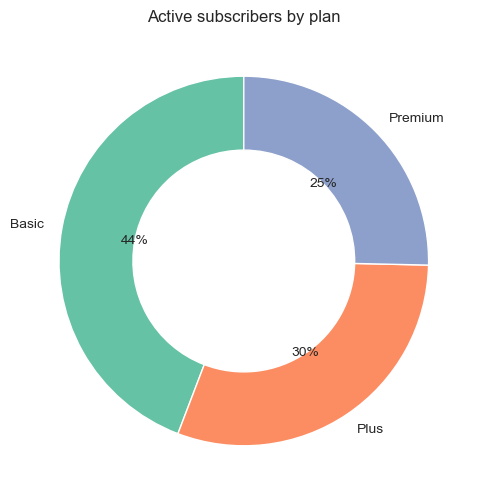

In [27]:
# donut chart of active subscribers by plan
plt.figure(figsize=(6, 6))
colors = plt.cm.Set2.colors[:len(plan_counts)]
plt.pie(
    plan_counts["count"],
    labels=plan_counts["plan"],
    autopct="%1.0f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"width": 0.4},
)
plt.title("Active subscribers by plan")
plt.show()

**Quick recap so far:** we have customers and subscriptions loaded, and we now know our conversion rate, churn rate, MRR, and ARPU. Next let's see if product usage has anything to do with who sticks around.

## Step 2 — Does product usage relate to retention?

`product_events.csv` logs every time a customer does something in the product (views a page, creates something, uses a feature, etc). Let's see if customers who use the product more are more likely to still be active.

In [29]:
df_events = pl.read_csv("product_events.csv", try_parse_dates=True)
df_events.head()

event_id,customer_id,event_timestamp,feature,event_type,platform,session_id
str,str,datetime[μs],str,str,str,str
"""EVT100000011""","""CUST100000""",2025-09-09 09:19:19,"""Payments""","""Created""","""Web""","""SESS-CUST100000-20250909-1"""
"""EVT100000006""","""CUST100000""",2025-09-10 06:45:36,"""Payments""","""Completed""","""Web""","""SESS-CUST100000-20250910-1"""
"""EVT100000008""","""CUST100000""",2025-09-10 16:50:39,"""Payments""","""Created""","""iOS""","""SESS-CUST100000-20250910-1"""
"""EVT100000003""","""CUST100000""",2025-09-13 16:13:53,"""Invoicing""","""Downloaded""","""Web""","""SESS-CUST100000-20250913-0"""
"""EVT100000016""","""CUST100000""",2025-09-18 13:15:50,"""Cash Flow""","""Viewed""","""Web""","""SESS-CUST100000-20250918-1"""


In [30]:
df_events.shape

(2273382, 7)

In [31]:
# this is a big file, so let's just count events per customer, one row per customer
events_per_customer = df_events.group_by("customer_id").agg(
    pl.len().alias("total_events")
)
events_per_customer.head()

customer_id,total_events
str,u32
"""CUST110969""",70
"""CUST107608""",16
"""CUST116793""",73
"""CUST122738""",121
"""CUST117334""",185


In [32]:
# what does a "typical" customer's usage look like?
events_per_customer["total_events"].describe()

statistic,value
str,f64
"""count""",50000.0
"""null_count""",0.0
"""mean""",45.46764
"""std""",45.741983
"""min""",1.0
"""25%""",15.0
"""50%""",30.0
"""75%""",60.0
"""max""",384.0


Let's split customers into three simple buckets — Low, Medium, High usage — using the 33rd and 66th percentile as the cut points.

In [33]:
cut_low = events_per_customer["total_events"].quantile(0.33)
cut_high = events_per_customer["total_events"].quantile(0.66)
print(f"Low cutoff: {cut_low}, High cutoff: {cut_high}")

Low cutoff: 19.0, High cutoff: 46.0


In [34]:
events_per_customer = events_per_customer.with_columns(
    pl.when(pl.col("total_events") <= cut_low).then(pl.lit("Low"))
      .when(pl.col("total_events") <= cut_high).then(pl.lit("Medium"))
      .otherwise(pl.lit("High"))
      .alias("engagement_level")
)
events_per_customer.head()

customer_id,total_events,engagement_level
str,u32,str
"""CUST110969""",70,"""High"""
"""CUST107608""",16,"""Low"""
"""CUST116793""",73,"""High"""
"""CUST122738""",121,"""High"""
"""CUST117334""",185,"""High"""


In [35]:
events_per_customer["engagement_level"].value_counts()

engagement_level,count
str,u32
"""Low""",17108
"""High""",17000
"""Medium""",15892


Now let's attach each customer's current subscription status (Active or Cancelled) so we can compare retention across the three usage buckets.

In [36]:
# just look at customers who actually paid at some point, and take their most recent subscription row
paid_customers_latest = (
    df_subs.filter(pl.col("plan") != "Free")
    .sort(["customer_id", "subscription_start_date"])
    .group_by("customer_id", maintain_order=True)
    .agg(pl.col("status").last())
)
paid_customers_latest.head()

customer_id,status
str,str
"""CUST100000""","""Active"""
"""CUST100002""","""Active"""
"""CUST100003""","""Active"""
"""CUST100004""","""Cancelled"""
"""CUST100006""","""Active"""


In [37]:
merged = paid_customers_latest.join(events_per_customer, on="customer_id", how="left")
merged.head()

customer_id,status,total_events,engagement_level
str,str,u32,str
"""CUST100000""","""Active""",24,"""Medium"""
"""CUST100002""","""Active""",28,"""Medium"""
"""CUST100003""","""Active""",58,"""High"""
"""CUST100004""","""Cancelled""",80,"""High"""
"""CUST100006""","""Active""",33,"""Medium"""


In [38]:
# for each engagement level, what % of customers are still Active?
retention_by_level = (
    merged.group_by("engagement_level")
    .agg([
        pl.len().alias("customers"),
        (pl.col("status") == "Active").mean().mul(100).round(1).alias("pct_still_active"),
    ])
    .sort("engagement_level")
)
retention_by_level

engagement_level,customers,pct_still_active
str,u32,f64
"""High""",10603,76.2
"""Low""",5973,61.9
"""Medium""",6778,66.7


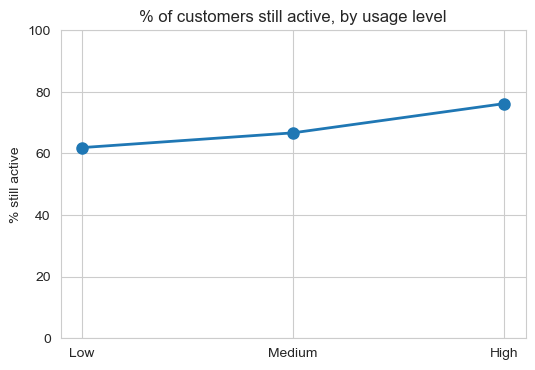

In [39]:
# line chart, ordered from lowest to highest engagement (instead of alphabetical)
order = ["Low", "Medium", "High"]
levels = retention_by_level["engagement_level"].to_list()
pct = retention_by_level["pct_still_active"].to_list()
lookup = dict(zip(levels, pct))
values_ordered = [lookup[level] for level in order]

plt.figure(figsize=(6, 4))
plt.plot(order, values_ordered, marker="o", markersize=8, linewidth=2)
plt.title("% of customers still active, by usage level")
plt.ylabel("% still active")
plt.ylim(0, 100)
plt.show()

**What this tells us:** if the High bar is a lot taller than the Low bar, that's a real signal — customers who actually use the product stick around more.

## Step 3 — Marketing funnel and A/B test results

First the marketing funnel: how many people saw an ad, clicked it, signed up, started a trial, and became paying customers.

In [45]:
df_campaigns = pl.read_csv(f"marketing_campaigns.csv", try_parse_dates=True)
df_campaigns.head()

campaign_id,campaign_name,channel,campaign_type,target_segment,start_date,end_date,budget,impressions,clicks
str,str,str,str,str,date,date,f64,i64,i64
"""CMP1047""","""Acquisition - Email - Medium B…","""Email""","""Acquisition""","""Medium Business""",2024-12-26,2025-03-03,3966.4,275,9
"""CMP1079""","""Acquisition - Referral - Mediu…","""Referral""","""Acquisition""","""Medium Business""",2025-12-01,2025-12-31,629.91,200,16
"""CMP1013""","""Acquisition - Display - All Cu…","""Display""","""Acquisition""","""All Customers""",2024-08-26,2024-10-08,3364.97,200,4
"""CMP1077""","""Subscription Offer - Referral …","""Referral""","""Subscription Offer""","""Small Business""",2025-02-14,2025-04-08,1223.69,200,15
"""CMP1096""","""Subscription Offer - Social Me…","""Social Media""","""Subscription Offer""","""All Customers""",2025-05-17,2025-05-31,2530.66,200,5


In [46]:
df_customer_campaigns = pl.read_csv(f"customer_campaigns.csv", try_parse_dates=True)
df_customer_campaigns.head()

customer_campaign_id,customer_id,campaign_id,impression_date,impression,clicked,signed_up,started_trial,converted_to_paid,revenue_generated
str,str,str,date,bool,bool,bool,bool,bool,f64
"""CC00007227""","""CUST104022""","""CMP1052""",2024-02-02,true,true,false,false,false,0.0
"""CC00065462""","""CUST136043""","""CMP1067""",2024-10-20,true,false,false,false,false,0.0
"""CC00062788""","""CUST134550""","""CMP1057""",2025-07-14,true,false,false,false,false,0.0
"""CC00058557""","""CUST132180""","""CMP1063""",2025-12-09,true,false,false,false,false,0.0
"""CC00083917""","""CUST146060""","""CMP1085""",2024-08-11,true,false,false,false,false,0.0


In [47]:
# these columns are True/False, so summing them counts how many were True
n_impressions = df_customer_campaigns["impression"].sum()
n_clicks = df_customer_campaigns["clicked"].sum()
n_signups = df_customer_campaigns["signed_up"].sum()
n_trials = df_customer_campaigns["started_trial"].sum()
n_paid = df_customer_campaigns["converted_to_paid"].sum()

print("Impressions:", n_impressions)
print("Clicks:     ", n_clicks)
print("Signups:    ", n_signups)
print("Trials:     ", n_trials)
print("Paid:       ", n_paid)

Impressions: 90996
Clicks:      17775
Signups:     4693
Trials:      2628
Paid:        1301


In [48]:
click_through_rate = n_clicks / n_impressions * 100
print(f"Click-through rate: {click_through_rate:.1f}%")

Click-through rate: 19.5%


In [49]:
overall_conversion = n_paid / n_impressions * 100
print(f"Impression -> paid conversion: {overall_conversion:.2f}%")

Impression -> paid conversion: 1.43%


Now let's see which marketing channel is the most cost-efficient (lowest cost per paying customer).

In [50]:
# attach the channel name (from campaigns) onto each customer-campaign row
cc_with_channel = df_customer_campaigns.join(
    df_campaigns.select(["campaign_id", "channel", "budget"]),
    on="campaign_id", how="left",
)
cc_with_channel.head()

customer_campaign_id,customer_id,campaign_id,impression_date,impression,clicked,signed_up,started_trial,converted_to_paid,revenue_generated,channel,budget
str,str,str,date,bool,bool,bool,bool,bool,f64,str,f64
"""CC00007227""","""CUST104022""","""CMP1052""",2024-02-02,true,true,false,false,false,0.0,"""Social Media""",946.45
"""CC00065462""","""CUST136043""","""CMP1067""",2024-10-20,true,false,false,false,false,0.0,"""Paid Search""",827.76
"""CC00062788""","""CUST134550""","""CMP1057""",2025-07-14,true,false,false,false,false,0.0,"""Partnership""",2016.67
"""CC00058557""","""CUST132180""","""CMP1063""",2025-12-09,true,false,false,false,false,0.0,"""Email""",8031.76
"""CC00083917""","""CUST146060""","""CMP1085""",2024-08-11,true,false,false,false,false,0.0,"""Referral""",4188.01


In [51]:
paid_by_channel = (
    cc_with_channel.group_by("channel")
    .agg(pl.col("converted_to_paid").sum().alias("paid_customers"))
)
paid_by_channel

channel,paid_customers
str,u32
"""Display""",105
"""Paid Search""",211
"""Email""",294
"""Social Media""",133
"""Partnership""",104
"""Push Notification""",188
"""Referral""",266


In [52]:
# budget is per-campaign, so add it up per channel separately, then join the two together
budget_by_channel = df_campaigns.group_by("channel").agg(pl.col("budget").sum().alias("total_budget"))

channel_summary = budget_by_channel.join(paid_by_channel, on="channel", how="left")
channel_summary = channel_summary.with_columns(
    (pl.col("total_budget") / pl.col("paid_customers")).round(2).alias("cost_per_paid_customer")
)
channel_summary.sort("cost_per_paid_customer")

channel,total_budget,paid_customers,cost_per_paid_customer
str,f64,u32,f64
"""Partnership""",26740.9,104,257.12
"""Referral""",68598.21,266,257.89
"""Paid Search""",63997.77,211,303.31
"""Push Notification""",66186.71,188,352.06
"""Email""",148929.8,294,506.56
"""Social Media""",85290.71,133,641.28
"""Display""",76918.71,105,732.56


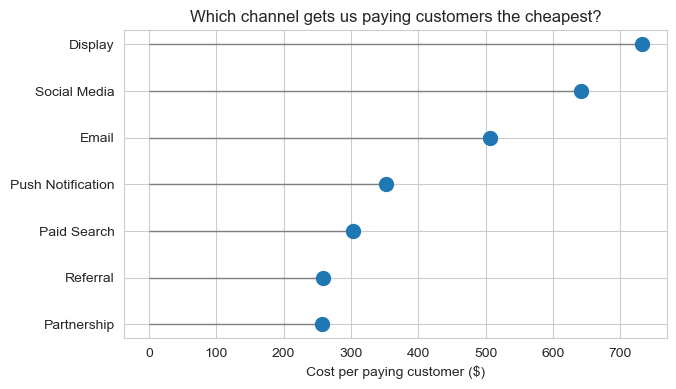

In [53]:
# lollipop chart: cheapest channel is at the top
plt.figure(figsize=(7, 4))
cs_sorted = channel_summary.sort("cost_per_paid_customer")
channels = cs_sorted["channel"]
costs = cs_sorted["cost_per_paid_customer"]

plt.hlines(y=channels, xmin=0, xmax=costs, color="grey", linewidth=1)
plt.plot(costs, channels, "o", markersize=10, color="tab:blue")
plt.xlabel("Cost per paying customer ($)")
plt.title("Which channel gets us paying customers the cheapest?")
plt.show()

### A/B experiments

Let's check our test results — did the "treatment" version actually convert better than "control"?

In [55]:
df_experiments = pl.read_csv(f"experiments.csv", try_parse_dates=True)
df_experiments.head()

experiment_id,customer_id,experiment_name,variant,assignment_date,eligible,converted,conversion_date,revenue_30d,retained_30d,retained_90d
str,str,str,str,date,bool,bool,date,f64,bool,bool
"""EXP01-0000864""","""CUST123117""","""Annual Plan Offer""","""Control""",2024-07-24,true,false,null,0.0,false,false
"""EXP02-0010915""","""CUST127139""","""Free Trial Length""","""Control""",2025-05-06,true,false,null,0.0,false,false
"""EXP03-0025794""","""CUST129039""","""Onboarding Flow""","""Control""",2025-06-01,true,false,null,0.0,false,false
"""EXP01-0008453""","""CUST108649""","""Annual Plan Offer""","""Treatment""",2025-10-01,true,false,null,0.0,false,false
"""EXP02-0014637""","""CUST120773""","""Free Trial Length""","""Control""",2025-12-26,true,false,null,0.0,false,false


In [56]:
df_experiments["experiment_name"].unique()

experiment_name
str
"""Subscription Pricing"""
"""Annual Plan Offer"""
"""Free Trial Length"""
"""Upgrade Prompt"""
"""Onboarding Flow"""


In [57]:
# for every experiment and variant (Control/Treatment), what % converted?
experiment_summary = (
    df_experiments.group_by(["experiment_name", "variant"])
    .agg([
        pl.len().alias("customers"),
        (pl.col("converted").mean() * 100).round(2).alias("conversion_pct"),
    ])
    .sort(["experiment_name", "variant"])
)
experiment_summary

experiment_name,variant,customers,conversion_pct
str,str,u32,f64
"""Annual Plan Offer""","""Control""",4287,25.29
"""Annual Plan Offer""","""Treatment""",4171,32.27
"""Free Trial Length""","""Control""",4135,25.25
"""Free Trial Length""","""Treatment""",4256,26.81
"""Onboarding Flow""","""Control""",5825,26.61
"""Onboarding Flow""","""Treatment""",5792,30.68
"""Subscription Pricing""","""Control""",4015,26.63
"""Subscription Pricing""","""Treatment""",4009,25.34
"""Upgrade Prompt""","""Control""",4789,25.45


In [58]:
# reshape so each experiment has one row: control % next to treatment %
control_vals = experiment_summary.filter(pl.col("variant") == "Control").sort("experiment_name")
treatment_vals = experiment_summary.filter(pl.col("variant") == "Treatment").sort("experiment_name")

exp_names = control_vals["experiment_name"].to_list()
control_pct = control_vals["conversion_pct"].to_list()
treatment_pct = treatment_vals["conversion_pct"].to_list()

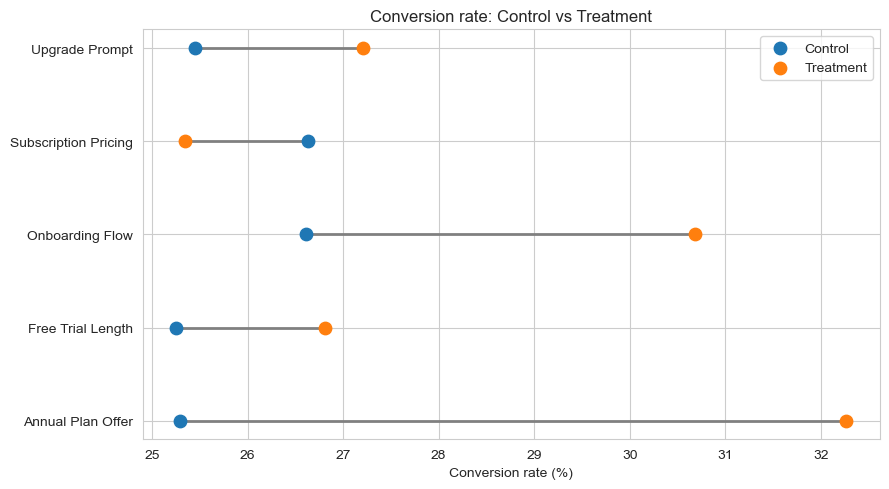

In [59]:
# dumbbell chart: one line per experiment connecting control -> treatment
plt.figure(figsize=(9, 5))
y_pos = range(len(exp_names))

plt.hlines(y=y_pos, xmin=control_pct, xmax=treatment_pct, color="grey", linewidth=2)
plt.scatter(control_pct, y_pos, color="tab:blue", s=80, label="Control", zorder=3)
plt.scatter(treatment_pct, y_pos, color="tab:orange", s=80, label="Treatment", zorder=3)

plt.yticks(list(y_pos), exp_names)
plt.xlabel("Conversion rate (%)")
plt.title("Conversion rate: Control vs Treatment")
plt.legend()
plt.tight_layout()
plt.show()

**Careful:** just because Treatment has a taller bar doesn't automatically mean it's a real, meaningful difference — a proper significance test would be needed to be sure. We're just eyeballing it here.

## Step 4 — Support tickets

Now let's look at customer support data: how many tickets, how fast we respond, how often we hit our SLA target, and how happy customers are with the outcome.

In [60]:
df_tickets = pl.read_csv(f"support_tickets.csv", try_parse_dates=True)
df_tickets.head()

ticket_id,customer_id,company_size,customer_segment,created_at,product_area,issue_type,priority,channel,first_response_at,first_response_hours,resolved_at,resolution_hours,status,escalated,reopened,fr_sla_target_hours,resolution_sla_target_hours,fr_sla_breached,resolution_sla_breached,sla_breached,feedback_given,csat_score
str,str,str,str,datetime[μs],str,str,str,str,datetime[μs],f64,datetime[μs],f64,str,bool,bool,i64,i64,bool,bool,bool,bool,i64
"""TKT300023282""","""CUST100002""","""Medium""","""New / Rising Subscribers""",2025-11-14 16:10:00,"""Cash Flow""","""Billing Issue""","""High""","""Phone""",2025-11-14 17:53:00,1.72,2025-11-15 11:50:49,17.96,"""Resolved""",false,false,4,24,false,false,false,true,4
"""TKT300023284""","""CUST100002""","""Medium""","""New / Rising Subscribers""",2025-11-25 12:22:00,"""Banking""","""Integration Issue""","""Low""","""Email""",2025-11-25 13:32:07,1.17,2025-11-26 05:43:50,16.2,"""Resolved""",false,false,48,120,false,false,false,true,5
"""TKT300023281""","""CUST100002""","""Medium""","""New / Rising Subscribers""",2025-12-06 19:22:00,"""Accounting""","""Data Discrepancy""","""Medium""","""In-App""",2025-12-06 21:34:24,2.21,2025-12-07 07:26:44,9.87,"""Resolved""",false,false,24,72,false,false,false,false,null
"""TKT300023283""","""CUST100002""","""Medium""","""New / Rising Subscribers""",2025-12-13 18:53:00,"""Payments""","""Feature Request""","""Medium""","""Email""",2025-12-13 22:54:39,4.03,2025-12-14 07:52:46,8.97,"""Resolved""",false,false,24,72,false,false,false,false,null
"""TKT300000226""","""CUST100004""","""Small""","""Churned / Lost Customers""",2025-06-04 14:07:00,"""Reporting""","""How-to Question""","""Critical""","""Chat""",2025-06-04 15:06:41,0.99,2025-06-04 17:47:34,2.68,"""Resolved""",false,false,1,8,false,false,false,false,null


In [61]:
df_tickets.shape

(28411, 23)

In [62]:
total_tickets = df_tickets.height
total_tickets

28411

In [63]:
resolved_tickets = df_tickets.filter(pl.col("status") == "Resolved").height
resolved_tickets

26806

In [64]:
resolution_rate = resolved_tickets / total_tickets * 100
print(f"Resolution rate: {resolution_rate:.1f}%")

Resolution rate: 94.4%


In [65]:
avg_first_response = df_tickets["first_response_hours"].mean()
print(f"Average first response time: {avg_first_response:.1f} hours")

Average first response time: 5.0 hours


In [66]:
# resolution_hours is empty (null) for tickets that aren't resolved yet, so .mean() just skips those
avg_resolution_time = df_tickets["resolution_hours"].mean()
print(f"Average resolution time: {avg_resolution_time:.1f} hours")

Average resolution time: 12.5 hours


In [67]:
# sla_breached is True/False, so the average of it IS the breach rate
sla_breach_rate = df_tickets["sla_breached"].mean() * 100
print(f"SLA breach rate: {sla_breach_rate:.1f}%")

SLA breach rate: 17.6%


In [68]:
# CSAT score only exists for tickets where the customer actually left feedback
tickets_with_feedback = df_tickets.filter(pl.col("feedback_given"))
avg_csat = tickets_with_feedback["csat_score"].mean()
print(f"Average CSAT: {avg_csat:.2f} out of 5")

Average CSAT: 3.81 out of 5


Which product area gets the most support tickets?

In [69]:
tickets_by_area = df_tickets["product_area"].value_counts().sort("count", descending=True)
tickets_by_area

product_area,count
str,u32
"""Payments""",4338
"""Invoicing""",3680
"""Banking""",3438
"""Expense Management""",3159
"""Accounting""",3044
"""Payroll""",3042
"""Reporting""",2841
"""Cash Flow""",2599
"""Business Card""",2270


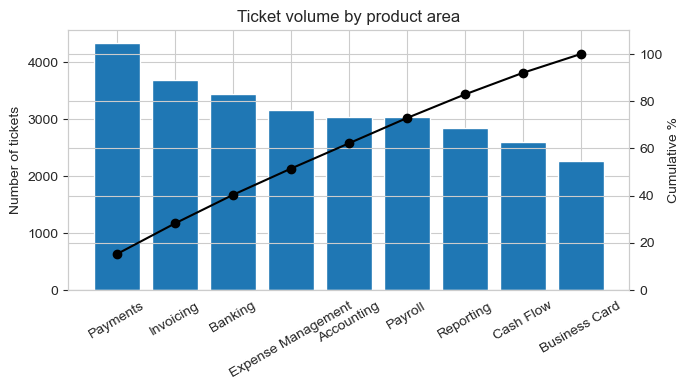

In [70]:
# pareto chart: bars for ticket volume, line for cumulative % of all tickets
areas = tickets_by_area["product_area"].to_list()
counts = tickets_by_area["count"].to_list()
cum_pct = np.cumsum(counts) / sum(counts) * 100

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.bar(areas, counts, color="tab:blue")
ax1.set_ylabel("Number of tickets")
ax1.set_title("Ticket volume by product area")
ax1.tick_params(axis="x", rotation=30)

ax2 = ax1.twinx()
ax2.plot(areas, cum_pct, color="black", marker="o")
ax2.set_ylabel("Cumulative %")
ax2.set_ylim(0, 110)

plt.tight_layout()
plt.show()

Which product area breaches its SLA target most often?

In [71]:
sla_by_area = (
    df_tickets.group_by("product_area")
    .agg((pl.col("sla_breached").mean() * 100).round(1).alias("sla_breach_pct"))
    .sort("sla_breach_pct", descending=True)
)
sla_by_area

product_area,sla_breach_pct
str,f64
"""Payroll""",21.9
"""Banking""",21.4
"""Reporting""",20.5
"""Invoicing""",16.9
"""Accounting""",16.6
"""Business Card""",15.9
"""Cash Flow""",15.9
"""Expense Management""",15.1
"""Payments""",15.0


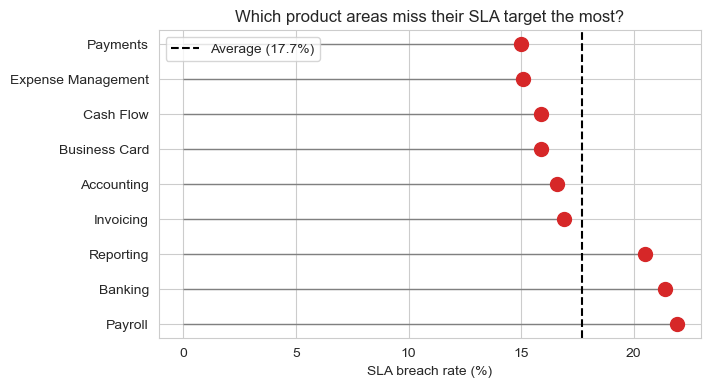

In [72]:
# lollipop chart with a dashed line marking the average breach rate across areas
plt.figure(figsize=(7, 4))
avg_breach = sla_by_area["sla_breach_pct"].mean()
areas = sla_by_area["product_area"]
breach = sla_by_area["sla_breach_pct"]

plt.hlines(y=areas, xmin=0, xmax=breach, color="grey", linewidth=1)
plt.plot(breach, areas, "o", markersize=10, color="tab:red")
plt.axvline(avg_breach, color="black", linestyle="--", label=f"Average ({avg_breach:.1f}%)")
plt.xlabel("SLA breach rate (%)")
plt.title("Which product areas miss their SLA target the most?")
plt.legend()
plt.show()

And which product area has the lowest CSAT (unhappiest customers)?

In [73]:
csat_by_area = (
    df_tickets.filter(pl.col("feedback_given"))
    .group_by("product_area")
    .agg(pl.col("csat_score").mean().round(2).alias("avg_csat"))
    .sort("avg_csat")
)
csat_by_area

product_area,avg_csat
str,f64
"""Banking""",3.7
"""Reporting""",3.71
"""Payroll""",3.72
"""Expense Management""",3.84
"""Business Card""",3.84
"""Invoicing""",3.85
"""Accounting""",3.85
"""Payments""",3.86
"""Cash Flow""",3.87


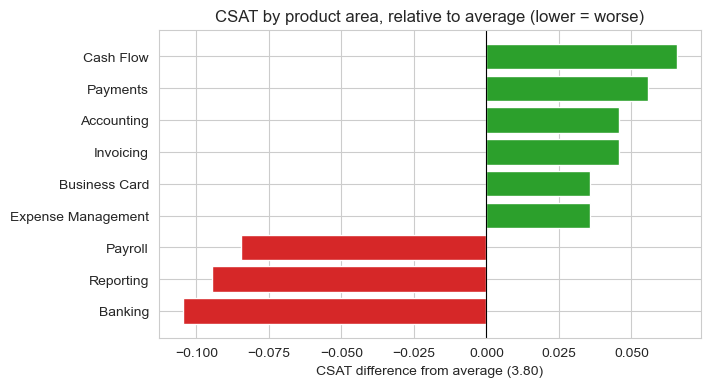

In [74]:
# diverging bar chart: how far each area\'s CSAT is from the overall average
plt.figure(figsize=(7, 4))
avg_csat_all = csat_by_area["avg_csat"].mean()
diff = (csat_by_area["avg_csat"] - avg_csat_all).to_list()
colors = ["tab:red" if d < 0 else "tab:green" for d in diff]

plt.barh(csat_by_area["product_area"], diff, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel(f"CSAT difference from average ({avg_csat_all:.2f})")
plt.title("CSAT by product area, relative to average (lower = worse)")
plt.show()

In [75]:
reopen_rate = df_tickets.filter(pl.col("status") == "Resolved")["reopened"].mean() * 100
print(f"Reopen rate (of resolved tickets): {reopen_rate:.1f}%")

Reopen rate (of resolved tickets): 11.8%


In [76]:
escalation_rate = df_tickets["escalated"].mean() * 100
print(f"Escalation rate: {escalation_rate:.1f}%")

Escalation rate: 11.7%


## Step 5 — What actually drives customer satisfaction?

Let's check: does missing the SLA target matter more to CSAT than how long a ticket takes overall? We'll use a simple correlation (`numpy.corrcoef`) to check.

In [77]:
fb = df_tickets.filter(pl.col("feedback_given"))
fb.shape

(16781, 23)

In [78]:
# turn True/False into 1/0 so we can correlate it with a number
sla_breached_numeric = fb["sla_breached"].cast(pl.Int8).to_numpy()
csat_values = fb["csat_score"].to_numpy()

correlation_sla = np.corrcoef(sla_breached_numeric, csat_values)[0, 1]
print(f"Correlation between SLA breach and CSAT: {correlation_sla:.3f}")

Correlation between SLA breach and CSAT: -0.484


In [79]:
resolution_hours_filled = fb["resolution_hours"].fill_null(fb["resolution_hours"].mean()).to_numpy()

correlation_resolution = np.corrcoef(resolution_hours_filled, csat_values)[0, 1]
print(f"Correlation between resolution time and CSAT: {correlation_resolution:.3f}")

Correlation between resolution time and CSAT: -0.091


In [80]:
print("SLA breach correlation: ", round(correlation_sla, 3))
print("Resolution time correlation:", round(correlation_resolution, 3))
# whichever number is bigger (ignoring the minus sign) matters more to CSAT

SLA breach correlation:  -0.484
Resolution time correlation: -0.091


Let's also just compare CSAT for Open vs Resolved tickets directly.

In [81]:
csat_by_status = (
    df_tickets.filter(pl.col("feedback_given"))
    .group_by("status")
    .agg(pl.col("csat_score").mean().round(2).alias("avg_csat"))
)
csat_by_status

status,avg_csat
str,f64
"""Open""",2.7
"""Resolved""",3.82


C:\Users\hp\AppData\Local\Temp\ipykernel_25596\677526413.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=statuses)


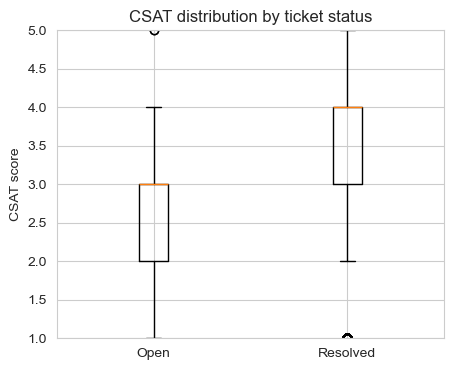

In [82]:
# box plot: shows the full distribution of CSAT scores, not just the average
statuses = csat_by_status["status"].to_list()
data = [
    df_tickets.filter(pl.col("feedback_given") & (pl.col("status") == s))["csat_score"].to_list()
    for s in statuses
]

plt.figure(figsize=(5, 4))
plt.boxplot(data, labels=statuses)
plt.ylabel("CSAT score")
plt.ylim(1, 5)
plt.title("CSAT distribution by ticket status")
plt.show()

## Step 6 — Which issues should we look at first?

Instead of a complicated scoring formula, let's just look at the same problem from three simple angles and see which issues keep showing up.

In [69]:
# group tickets by product area + issue type, and calculate the basics for each group
issue_summary = (
    df_tickets.group_by(["product_area", "issue_type"])
    .agg([
        pl.len().alias("ticket_count"),
        (pl.col("sla_breached").mean() * 100).round(1).alias("sla_breach_pct"),
        pl.col("resolution_hours").mean().round(1).alias("avg_resolution_hours"),
    ])
)
issue_summary.head()

product_area,issue_type,ticket_count,sla_breach_pct,avg_resolution_hours
str,str,u32,f64,f64
"""Accounting""","""Account Access""",294,20.7,7.5
"""Reporting""","""Data Discrepancy""",285,20.4,25.3
"""Accounting""","""Bug""",626,26.5,11.5
"""Expense Management""","""Performance Issue""",317,7.9,11.2
"""Payroll""","""Account Access""",316,22.8,11.8


In [70]:
# add average CSAT separately, since it only applies to tickets with feedback
csat_per_issue = (
    df_tickets.filter(pl.col("feedback_given"))
    .group_by(["product_area", "issue_type"])
    .agg(pl.col("csat_score").mean().round(2).alias("avg_csat"))
)

issue_summary = issue_summary.join(csat_per_issue, on=["product_area", "issue_type"], how="left")
issue_summary.head()

product_area,issue_type,ticket_count,sla_breach_pct,avg_resolution_hours,avg_csat
str,str,u32,f64,f64,f64
"""Accounting""","""Account Access""",294,20.7,7.5,3.74
"""Reporting""","""Data Discrepancy""",285,20.4,25.3,3.66
"""Accounting""","""Bug""",626,26.5,11.5,3.7
"""Expense Management""","""Performance Issue""",317,7.9,11.2,3.93
"""Payroll""","""Account Access""",316,22.8,11.8,3.65


In [71]:
# only look at issues with a reasonable number of tickets, otherwise the averages are noisy
issue_summary = issue_summary.filter(pl.col("ticket_count") >= 15)
issue_summary.shape

(72, 6)

In [72]:
print("Highest volume issues:")
issue_summary.sort("ticket_count", descending=True).head(5)

Highest volume issues:


product_area,issue_type,ticket_count,sla_breach_pct,avg_resolution_hours,avg_csat
str,str,u32,f64,f64,f64
"""Payments""","""How-to Question""",968,7.7,10.1,3.96
"""Payments""","""Bug""",875,24.3,10.7,3.68
"""Invoicing""","""How-to Question""",805,11.1,9.4,3.89
"""Banking""","""How-to Question""",759,13.6,15.6,3.83
"""Invoicing""","""Bug""",754,26.5,10.4,3.64


In [73]:
print("Worst SLA breach rate:")
issue_summary.sort("sla_breach_pct", descending=True).head(5)

Worst SLA breach rate:


product_area,issue_type,ticket_count,sla_breach_pct,avg_resolution_hours,avg_csat
str,str,u32,f64,f64,f64
"""Payroll""","""Bug""",575,32.3,18.4,3.53
"""Banking""","""Bug""",692,31.2,18.6,3.54
"""Reporting""","""Bug""",550,29.8,17.2,3.61
"""Payroll""","""Integration Issue""",209,27.3,28.3,3.72
"""Accounting""","""Bug""",626,26.5,11.5,3.7


In [74]:
print("Lowest CSAT:")
issue_summary.sort("avg_csat").head(5)

Lowest CSAT:


product_area,issue_type,ticket_count,sla_breach_pct,avg_resolution_hours,avg_csat
str,str,u32,f64,f64,f64
"""Payroll""","""Bug""",575,32.3,18.4,3.53
"""Banking""","""Bug""",692,31.2,18.6,3.54
"""Banking""","""Billing Issue""",492,23.4,12.6,3.61
"""Reporting""","""Bug""",550,29.8,17.2,3.61
"""Expense Management""","""Bug""",619,24.7,11.8,3.62


Let's flag an issue as **High Priority** if it's above-average on volume AND above-average on SLA breach rate — a simple rule, not a fancy formula.

In [75]:
avg_ticket_count = issue_summary["ticket_count"].mean()
avg_breach_pct = issue_summary["sla_breach_pct"].mean()

print(f"Average ticket count across issues: {avg_ticket_count:.0f}")
print(f"Average SLA breach rate across issues: {avg_breach_pct:.1f}%")

Average ticket count across issues: 395
Average SLA breach rate across issues: 17.2%


In [76]:
issue_summary = issue_summary.with_columns(
    ((pl.col("ticket_count") > avg_ticket_count) & (pl.col("sla_breach_pct") > avg_breach_pct))
    .alias("high_priority")
)

high_priority_issues = issue_summary.filter(pl.col("high_priority")).sort("ticket_count", descending=True)
high_priority_issues

product_area,issue_type,ticket_count,sla_breach_pct,avg_resolution_hours,avg_csat,high_priority
str,str,u32,f64,f64,f64,bool
"""Payments""","""Bug""",875,24.3,10.7,3.68,true
"""Invoicing""","""Bug""",754,26.5,10.4,3.64,true
"""Banking""","""Bug""",692,31.2,18.6,3.54,true
"""Accounting""","""Bug""",626,26.5,11.5,3.7,true
"""Expense Management""","""Bug""",619,24.7,11.8,3.62,true
…,…,…,…,…,…,…
"""Accounting""","""Billing Issue""",425,22.6,8.8,3.84,true
"""Payments""","""Account Access""",416,19.5,7.4,3.86,true
"""Payroll""","""Billing Issue""",413,25.4,14.5,3.67,true


In [77]:
print(f"{high_priority_issues.height} issues flagged as high priority out of {issue_summary.height} total")

17 issues flagged as high priority out of 72 total


In [ ]:
# bubble chart: SLA breach rate vs CSAT, bubble size = ticket volume, red = flagged high priority
plt.figure(figsize=(8, 5))
flags = issue_summary["high_priority"].to_list()
colors = ["tab:red" if f else "tab:blue" for f in flags]
sizes = [c / 2 for c in issue_summary["ticket_count"].to_list()]

plt.scatter(
    issue_summary["sla_breach_pct"],
    issue_summary["avg_csat"],
    s=sizes,
    c=colors,
    alpha=0.6,
    edgecolors="black",
)
plt.axvline(avg_breach_pct, color="grey", linestyle="--", linewidth=1)
plt.xlabel("SLA breach rate (%)")
plt.ylabel("Average CSAT")
plt.title("Issues by SLA breach rate and CSAT (bubble size = ticket volume, red = high priority)")
plt.show()

## Wrap-up

That's the whole walkthrough: subscriptions and revenue, whether engagement predicts retention, marketing funnel and channel efficiency, A/B test results, and support ticket patterns — ending with a simple (not fancy) way to flag which issues deserve a closer look.

This notebook intentionally keeps every step small and readable. For the fuller, production-style version of this analysis (with proper statistical tests, a hand-written K-Means segmentation, and a weighted issue-prioritisation framework), see `subscription_product_analytics_full_pipeline.ipynb` and the scripts in `scripts/`.